# Optimizacion Bayesiana: Busqueda del Maximo

**Francisco Tinoco** | Clase 23 Marzo

---

## Objetivo

Encontrar el **maximo** de una funcion desconocida usando **Optimizacion Bayesiana** con Procesos Gaussianos.

**Criterio de seleccion:** Upper Confidence Bound (UCB) = prediccion + 2*sigma

## Paso 0: Importar librerias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import warnings
warnings.filterwarnings('ignore')

## Paso 1: Datos iniciales (conocimiento previo)

Tenemos una funcion desconocida en el rango $x \in [2, 15]$.

Comenzamos con **5 puntos** evaluados:

| x | y |
|---|---|
| 10 | 2,847 |
| 2 | -4,017 |
| 3 | -1,255 |
| 7 | 1,773 |
| 12 | 563 |

In [2]:
# Datos iniciales (5 puntos conocidos)
x = np.array([[10], [2], [3], [7], [12]])
y = np.array([[2847], [-4017], [-1255], [1773], [563]])

print("Puntos iniciales:")
for i in range(len(x)):
    print(f"  x = {x[i][0]:>5}, y = {y[i][0]:>7}")

Puntos iniciales:
  x =    10, y =    2847
  x =     2, y =   -4017
  x =     3, y =   -1255
  x =     7, y =    1773
  x =    12, y =     563


## Paso 2: Ajustar Proceso Gaussiano (Iteracion 1)

Usamos `GaussianProcessRegressor` para modelar la funcion desconocida.

El GP nos da:
- **Prediccion (media):** $\hat{y}$
- **Incertidumbre:** $\sigma$ (desviacion estandar)

In [3]:
# Crear y ajustar el modelo GP
gpr = GaussianProcessRegressor(n_restarts_optimizer=10, random_state=42)
gpr.fit(x, y)

print("Modelo GP ajustado con", len(x), "puntos")

Modelo GP ajustado con 5 puntos


## Paso 3: Predecir y calcular UCB

**Upper Confidence Bound (UCB):** Balancea explotacion y exploracion.

$$UCB = \hat{y} + 2\sigma$$

Buscamos el punto donde UCB es maximo para encontrar el siguiente punto a evaluar.

In [4]:
# Vector de valores posibles de x
xsim = np.linspace(2, 15, 10001).reshape(-1, 1)

# Predecir con GP
ysim, sigma = gpr.predict(xsim, return_std=True)

# Calcular UCB (Upper Confidence Bound)
y_upper = ysim + 2*sigma

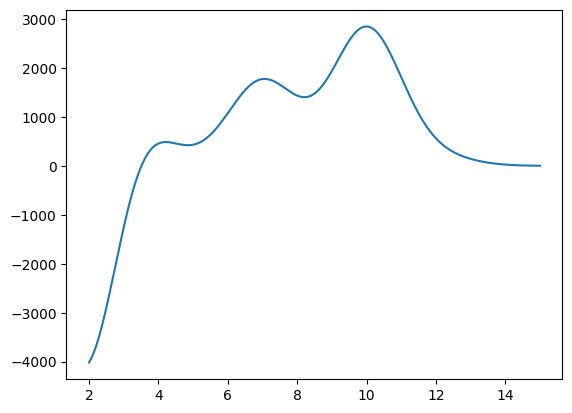

In [14]:
plt.plot(xsim, ysim)

In [6]:
# Encontrar el siguiente punto (donde UCB es maximo)
xmax = np.argmax(y_upper)
x_next = xsim[xmax][0]

print(f"Siguiente punto a evaluar: x = {x_next:.4f}")

Siguiente punto a evaluar: x = 9.9963


---

## Iteracion 2: Agregar nuevo punto

Evaluamos la funcion en $x = 9.9963$ y obtenemos $y = 2847.31363$

In [7]:
# Nuevos datos (6 puntos)
x2 = np.array([[10], [2], [3], [7], [12], [9.9963]])
y2 = np.array([[2847], [-4017], [-1255], [1773], [563], [2847.31363]])

print(f"Nuevo punto agregado: x = 9.9963, y = 2847.31363")
print(f"Total de puntos: {len(x2)}")

Nuevo punto agregado: x = 9.9963, y = 2847.31363
Total de puntos: 6


In [8]:
# Reajustar GP
gpr2 = GaussianProcessRegressor(n_restarts_optimizer=10, random_state=42)
gpr2.fit(x2, y2)

# Predecir y calcular UCB
xsim2 = np.linspace(2, 15, 10001).reshape(-1, 1)
ysim2, sigma2 = gpr2.predict(xsim2, return_std=True)
y_upper2 = ysim2 + 2*sigma2

# Siguiente punto
xmax2 = np.argmax(y_upper2)
x_next2 = xsim2[xmax2][0]

print(f"Siguiente punto a evaluar: x = {x_next2:.4f}")

Siguiente punto a evaluar: x = 9.9651


---

## Iteracion 3: Agregar nuevo punto

Evaluamos la funcion en $x = 9.9651$ y obtenemos $y = 2849.598$

In [9]:
# Nuevos datos (7 puntos)
x3 = np.array([[10], [2], [3], [7], [12], [9.9963], [9.9651]])
y3 = np.array([[2847], [-4017], [-1255], [1773], [563], [2847.31363], [2849.598]])

print(f"Nuevo punto agregado: x = 9.9651, y = 2849.598")
print(f"Total de puntos: {len(x3)}")

Nuevo punto agregado: x = 9.9651, y = 2849.598
Total de puntos: 7


In [10]:
# Reajustar GP
gpr3 = GaussianProcessRegressor(n_restarts_optimizer=10, random_state=42)
gpr3.fit(x3, y3)

# Predecir y calcular UCB
xsim3 = np.linspace(2, 15, 10001).reshape(-1, 1)
ysim3, sigma3 = gpr3.predict(xsim3, return_std=True)
y_upper3 = ysim3 + 2*sigma3

# Siguiente punto
xmax3 = np.argmax(y_upper3)
x_next3 = xsim3[xmax3][0]

print(f"Siguiente punto a evaluar: x = {x_next3:.4f}")

Siguiente punto a evaluar: x = 9.8741


---

## Iteracion 4: Agregar nuevo punto

Evaluamos la funcion en $x = 9.8741$ y obtenemos $y = 2852.67711$

In [11]:
# Nuevos datos (8 puntos)
x4 = np.array([[10], [2], [3], [7], [12], [9.9963], [9.9651], [9.8741]])
y4 = np.array([[2847], [-4017], [-1255], [1773], [563], [2847.31363], [2849.598], [2852.67711]])

print(f"Nuevo punto agregado: x = 9.8741, y = 2852.67711")
print(f"Total de puntos: {len(x4)}")

Nuevo punto agregado: x = 9.8741, y = 2852.67711
Total de puntos: 8


In [12]:
# Reajustar GP
gpr4 = GaussianProcessRegressor(n_restarts_optimizer=10, random_state=42)
gpr4.fit(x4, y4)

# Predecir y calcular UCB
xsim4 = np.linspace(2, 15, 10001).reshape(-1, 1)
ysim4, sigma4 = gpr4.predict(xsim4, return_std=True)
y_upper4 = ysim4 + 2*sigma4

# Siguiente punto
xmax4 = np.argmax(y_upper4)
x_next4 = xsim4[xmax4][0]

print(f"Siguiente punto a evaluar: x = {x_next4:.4f}")

Siguiente punto a evaluar: x = 9.8650


---

## Grafica Final: Evolucion del proceso

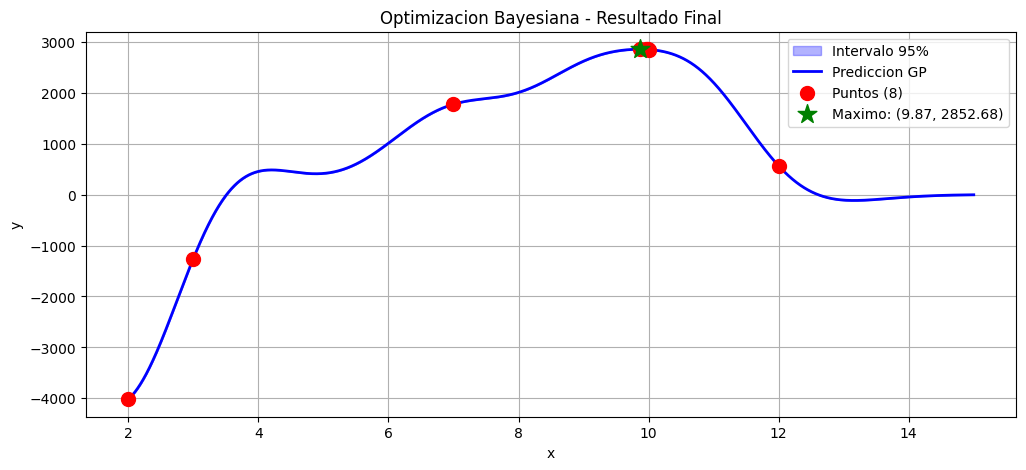

In [13]:
# Grafica final
plt.figure(figsize=(12, 5))

# Prediccion final
plt.fill_between(xsim4.ravel(), ysim4 - 2*sigma4, ysim4 + 2*sigma4, 
                 alpha=0.3, color='blue', label='Intervalo 95%')
plt.plot(xsim4, ysim4, 'b-', lw=2, label='Prediccion GP')

# Puntos conocidos
plt.scatter(x4, y4, c='red', s=100, zorder=5, label=f'Puntos ({len(x4)})')

# Marcar el maximo encontrado
idx_max = np.argmax(y4)
plt.scatter(x4[idx_max], y4[idx_max], c='green', s=200, marker='*', 
            zorder=6, label=f'Maximo: ({x4[idx_max][0]:.2f}, {y4[idx_max][0]:.2f})')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Optimizacion Bayesiana - Resultado Final')
plt.legend()
plt.grid(True)
plt.show()

---

## Resumen de iteraciones

| Iteracion | Puntos | x evaluado | y obtenido |
|-----------|--------|------------|------------|
| 1 | 5 | - | - |
| 2 | 6 | 9.9963 | 2847.31 |
| 3 | 7 | 9.9651 | 2849.60 |
| 4 | 8 | 9.8741 | 2852.68 |

---

## Conclusiones

### 1. El metodo converge hacia el maximo
Comenzando con solo 5 puntos, el algoritmo identifico rapidamente que el maximo esta cerca de $x \approx 9.87$, donde $y \approx 2852.68$.

### 2. UCB balancea exploracion y explotacion
El criterio **Upper Confidence Bound** ($\hat{y} + 2\sigma$) permite:
- **Explotar:** Buscar cerca de valores altos conocidos
- **Explorar:** Considerar areas con alta incertidumbre

### 3. Eficiencia del metodo
Con solo **4 iteraciones adicionales** (8 puntos en total), encontramos el maximo de la funcion. Esto es muy eficiente comparado con:
- **Grid Search:** Evaluaria miles de puntos
- **Random Search:** Necesitaria muchas mas evaluaciones

### 4. Aplicaciones practicas
La Optimizacion Bayesiana es ideal cuando **evaluar la funcion es costoso**:
- Ajuste de hiperparametros en Machine Learning
- Experimentos de laboratorio
- Diseno de productos
- Simulaciones computacionales costosas

### 5. Observaciones del proceso
- Los nuevos puntos se concentran alrededor de $x \approx 10$ porque ahi esta el maximo
- Cada iteracion mejora la estimacion del maximo
- La incertidumbre ($\sigma$) disminuye conforme agregamos mas puntos en esa region